<a href="https://colab.research.google.com/github/cluffbradley/credit-card-fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost scikit-learn pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

print("All libraries loaded!")

All libraries loaded!


In [5]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv.zip to creditcard.csv (1).zip


In [7]:
import zipfile

# Unzip the uploaded file
zip_file_path = 'creditcard.csv (1).zip'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv('creditcard.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Total Transactions: {len(df):,}')
print(f'Fraudulent Transactions: {df["Class"].sum():,}')
print(f'Legitimate Transactions: {(df["Class"] == 0).sum():,}')
print(f'Fraud Rate: {df["Class"].mean()*100:.3f}%')

Dataset Shape: (284807, 31)
Total Transactions: 284,807
Fraudulent Transactions: 492
Legitimate Transactions: 284,315
Fraud Rate: 0.173%


In [8]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


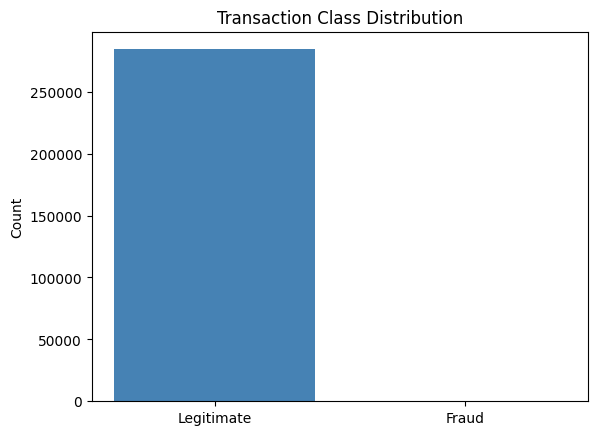

Legitimate: 284,315
Fraud: 492


In [9]:
# Visualize class imbalance
import matplotlib.pyplot as plt

class_counts = df['Class'].value_counts()
plt.bar(['Legitimate', 'Fraud'], class_counts.values, color=['steelblue', 'crimson'])
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.show()

print(f'Legitimate: {class_counts[0]:,}')
print(f'Fraud: {class_counts[1]:,}')

In [10]:
# Scale the Amount and Time columns
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df = df.drop(columns=['Amount', 'Time'])

print('Feature engineering complete!')
print(f'New shape: {df.shape}')


Feature engineering complete!
New shape: (284807, 31)


In [11]:
# Define features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples: {X_test.shape[0]:,}')


Training samples: 227,845
Test samples: 56,962


In [12]:
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('Random Forest training complete!')

Training Random Forest...
Random Forest training complete!


In [13]:
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('--- Random Forest Results ---')
print(classification_report(y_test, rf_pred, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, rf_pred_proba):.4f}')

--- Random Forest Results ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.81      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9804


In [14]:
print('Training XGBoost...')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)
xgb_model.fit(X_train, y_train)
print('XGBoost training complete!')

Training XGBoost...
XGBoost training complete!


In [15]:
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print('--- XGBoost Results ---')
print(classification_report(y_test, xgb_pred, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, xgb_pred_proba):.4f}')

--- XGBoost Results ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9724


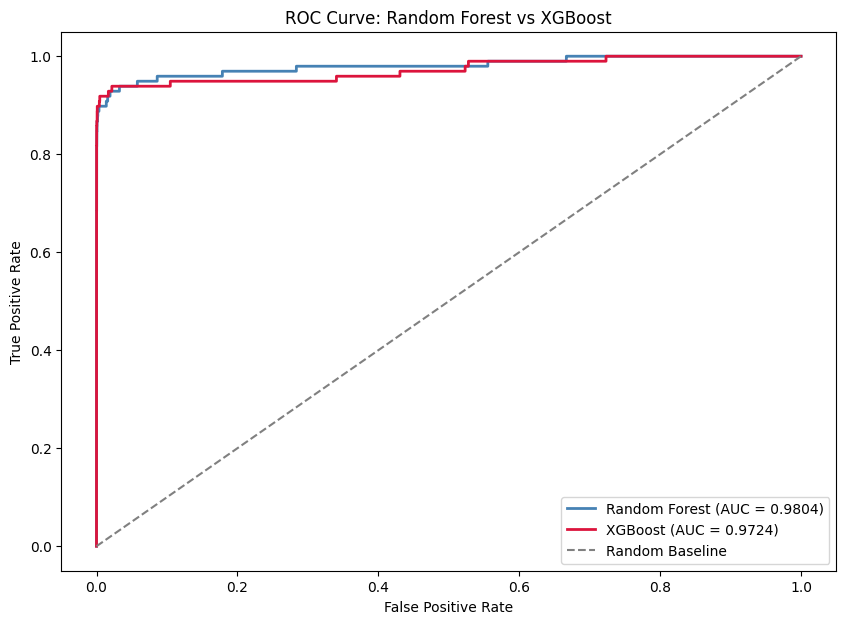

In [16]:
# ROC Curve Comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, color='steelblue', lw=2, label=f'Random Forest (AUC = 0.9804)')
plt.plot(fpr_xgb, tpr_xgb, color='crimson', lw=2, label=f'XGBoost (AUC = 0.9724)')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Random Forest vs XGBoost')
plt.legend()
plt.show()

/tmp/ipykernel_18453/388476294.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


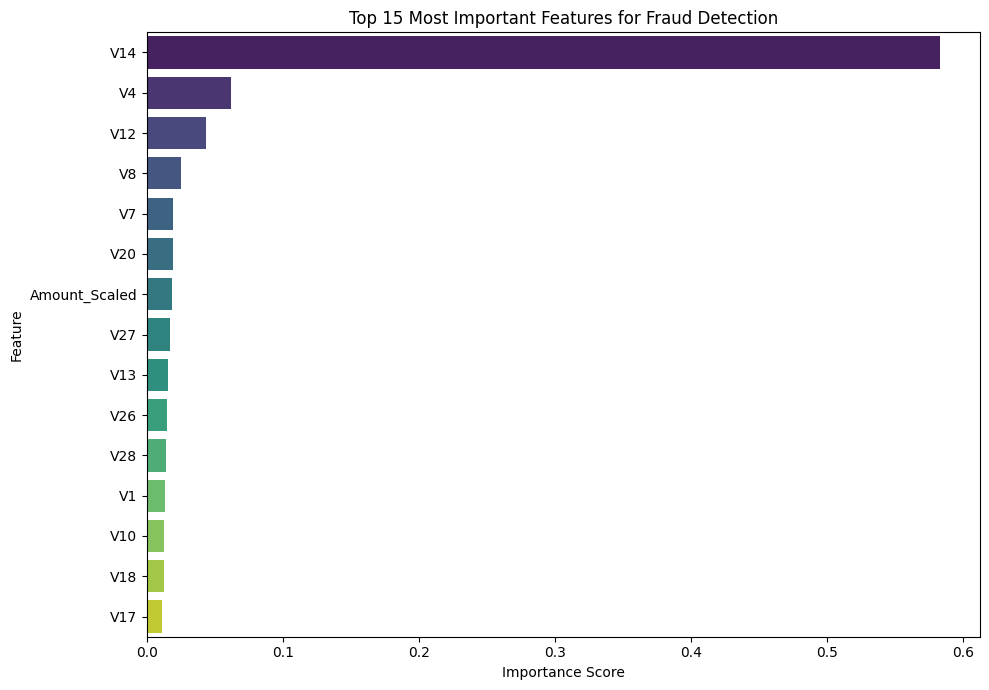

In [17]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 15 Most Important Features for Fraud Detection')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
